# Customer Churn Prediction – Supervised Learning

## Business Problem

A subscription-based company is experiencing customer churn. 
The management wants to identify customers who are likely to leave 
so that the retention team can intervene before the customer churns.

## Objective

The objective of this project is to build a supervised machine learning 
classification solution that predicts whether a customer is likely to churn 
(`Yes` or `No`) and evaluate how reliably the models perform on unseen data.

## Dataset

The dataset contains customer demographic, usage, billing, service, 
and satisfaction information. It intentionally contains several 
real-world data-quality issues that need to be investigated and handled 
before model building.

## Target Variable

`Churn`

- `Yes` → Customer churned / is classified as churn
- `No` → Customer did not churn / is classified as non-churn

## Problem Type

This is a **binary classification** problem because the target variable 
has two possible classes: `Yes` and `No`.

## 1. Import Required Libraries

The following libraries will be used for:

- `pandas` – data loading, inspection, cleaning, and analysis
- `numpy` – numerical operations
- `matplotlib` – visualization
- `seaborn` – exploratory data visualization

Machine learning libraries will be imported later when we reach the 
preprocessing and modeling stages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The raw customer churn dataset is loaded into a pandas DataFrame.

At this stage, the data is loaded without applying any cleaning or 
preprocessing. This is important because the project requires us to 
first inspect and understand the raw data and identify its data-quality 
issues before making cleaning decisions.

In [2]:
file_path = "Supervised_Learning_Messy_Customer_Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Initial Inspection of the Raw Dataset

Before cleaning the data, we inspect the first few records to understand 
the structure and values present in the raw dataset.

No rows are removed or modified at this stage.

In [3]:
df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


### 3.1 Dataset Shape

The shape of the DataFrame is checked to determine the number of 
observations and variables present in the raw dataset.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Shape:", df.shape)

Number of rows: 184
Number of columns: 13
Shape: (184, 13)


### 3.2 Column Names

The column names are inspected to identify the available customer 
attributes, the identifier column, and the target variable.

In [5]:
print("Column names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column names:
1. Customer_ID
2. Age
3. Annual_Income
4. Tenure_Months
5. Monthly_Charges
6. Support_Calls_Last_3M
7. Data_Usage_GB
8. Satisfaction_Score
9. Contract_Type
10. Payment_Method
11. Region
12. Plan_Type
13. Churn


### 3.3 Data Types

The data types of all columns are inspected before cleaning.

This step is important because the raw dataset intentionally contains 
data-quality issues. Some columns that are conceptually numerical may 
contain placeholder values such as `?`, which can cause pandas to interpret 
the column as an object/string rather than a numeric variable.

Therefore, data types will be investigated before any conversion is performed.

In [7]:
df.dtypes

Customer_ID                  str
Age                      float64
Annual_Income                str
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type                str
Payment_Method               str
Region                       str
Plan_Type                    str
Churn                        str
dtype: object

### 3.4 Dataset Information

The `info()` method is used to inspect:

- Number of non-null values
- Missing values
- Data types
- Memory usage

This provides an initial view of data completeness and structure.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            184 non-null    str    
 1   Age                    176 non-null    float64
 2   Annual_Income          173 non-null    str    
 3   Tenure_Months          177 non-null    float64
 4   Monthly_Charges        178 non-null    float64
 5   Support_Calls_Last_3M  179 non-null    float64
 6   Data_Usage_GB          178 non-null    float64
 7   Satisfaction_Score     178 non-null    float64
 8   Contract_Type          184 non-null    str    
 9   Payment_Method         184 non-null    str    
 10  Region                 184 non-null    str    
 11  Plan_Type              184 non-null    str    
 12  Churn                  184 non-null    str    
dtypes: float64(6), str(7)
memory usage: 18.8 KB


### 3.5 Descriptive Statistics

Descriptive statistics are generated for the numerical variables.

This helps identify unusual ranges, extreme values, and potential 
data-quality issues that need further investigation.

The values observed here are not automatically removed. Any suspicious 
values will be investigated before a cleaning decision is made.

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,184,180,CUST-1043,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,176.0,NaN,NaN,NaN,36.164773,12.865951,-5.0,29.0,36.0,41.0,145.0
Annual_Income,173,156,76600.0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure_Months,177.0,NaN,NaN,NaN,39.39548,21.545185,1.0,25.0,38.0,55.0,150.0
Monthly_Charges,178.0,NaN,NaN,NaN,80.205899,74.17937,0.0,57.885,73.565,90.28,999.0
Support_Calls_Last_3M,179.0,NaN,NaN,NaN,3.217877,2.577455,0.0,2.0,3.0,4.0,30.0
Data_Usage_GB,178.0,NaN,NaN,NaN,17.80618,9.245516,-10.0,11.6,18.2,24.2,44.0
Satisfaction_Score,178.0,NaN,NaN,NaN,5.803371,2.947869,1.0,4.0,6.0,8.0,15.0
Contract_Type,184,8,Monthly,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment_Method,184,9,Bank Transfer,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Missing Value Investigation

Missing values are investigated in the raw dataset before deciding how 
they should be handled.

We will also investigate placeholder values such as `?`, `N/A`, and `NA`, 
because these may represent missing information without being stored as 
actual pandas `NaN` values.

No imputation is performed at this stage.

In [10]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
})

missing_summary

,Missing_Count,Missing_Percentage
Customer_ID,0,0.00
Age,8,4.35
Annual_Income,11,5.98
Tenure_Months,7,3.80
Monthly_Charges,6,3.26
Support_Calls_Last_3M,5,2.72
Data_Usage_GB,6,3.26
Satisfaction_Score,6,3.26
Contract_Type,0,0.00
Payment_Method,0,0.00


### 4.1 Placeholder Value Investigation

The raw dataset is checked for common placeholder values such as:

- `?`
- `N/A`
- `NA`
- `n/a`
- `na`

These values may represent missing information but are not necessarily 
recognized by pandas as missing values after loading the CSV.

In [11]:
placeholder_values = ["?", "N/A", "NA", "n/a", "na"]

for value in placeholder_values:
    count = (df.astype(str) == value).sum().sum()
    print(f"{value}: {count}")

?: 4
N/A: 0
NA: 0
n/a: 0
na: 0


## 5. Duplicate Record Investigation

Duplicate records are investigated before deciding whether any records 
should be removed.

Exact duplicate rows are checked using all columns.

If exact duplicates are present, they will be reviewed before removal 
because duplicate records can cause the same observation to receive 
additional weight during model training.

In [12]:
duplicate_count = df.duplicated().sum()

print("Number of exact duplicate rows:", duplicate_count)

Number of exact duplicate rows: 4


### 5.1 Display Exact Duplicate Records

The exact duplicate rows are displayed to verify that they are genuinely 
identical records before deciding how to handle them.

In [13]:
duplicates = df[df.duplicated(keep=False)].sort_values(by="Customer_ID")

duplicates

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
132,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
154,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
119,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
46,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
71,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
169,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No


### 5.1 Inspect Exact Duplicate Records

The exact duplicate records identified in the previous step are displayed
for verification.

This helps confirm whether the duplicated rows contain identical customer
information before deciding how they should be handled.

In [14]:
duplicates = df[df.duplicated(keep=False)].sort_values(by="Customer_ID")

duplicates

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
132,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
154,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
119,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
46,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
71,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
169,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No


### 5.2 Verify Duplicate Records

The dataset contains repeated Customer_ID values, but repeated IDs do not
necessarily mean that the complete records are identical.

We therefore check:
1. The number of unique Customer_ID values.
2. Whether each repeated Customer_ID has exactly identical records.
3. Whether any repeated Customer_ID contains conflicting or missing values.

This helps us decide which records can safely be removed without losing
potentially useful information.

In [15]:
# Check Customer_IDs that occur more than once
customer_id_counts = df["Customer_ID"].value_counts()

repeated_customer_ids = customer_id_counts[customer_id_counts > 1]

repeated_customer_ids

Customer_ID
CUST-1043    2
CUST-1110    2
CUST-1008    2
CUST-1152    2
Name: count, dtype: int64

In [16]:
# Display all records belonging to repeated Customer_IDs
duplicate_records = df[df["Customer_ID"].isin(repeated_customer_ids.index)]

duplicate_records.sort_values("Customer_ID")

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
132,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
154,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
119,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
46,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
71,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
169,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No


In [17]:
# Count the number of duplicate rows
print("Total rows:", len(df))
print("Exact duplicate rows:", df.duplicated().sum())
print("Rows after removing exact duplicates:", len(df.drop_duplicates()))

Total rows: 184
Exact duplicate rows: 4
Rows after removing exact duplicates: 180


In [18]:
# Check missing values in each column
missing_values = df.isnull().sum()

missing_values

Customer_ID               0
Age                       8
Annual_Income            11
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             0
Payment_Method            0
Region                    0
Plan_Type                 0
Churn                     0
dtype: int64

## 5. Categorical Value Consistency Check

Categorical columns were examined for inconsistent labels caused by differences in capitalization, spacing, or spelling.

For example, values such as `Monthly`, `monthly`, and `MONTHLY` represent the same category but may be treated as different values by a machine learning model.

These inconsistencies will be standardized before model training.

In [19]:
# Check unique values in categorical columns

categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type",
    "Churn"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


Contract_Type:
<StringArray>
['MONTHLY', 'Monthly', '1 Year', '2 Year', '2-Year', '1 year', 'monthly', '?']
Length: 8, dtype: str

Payment_Method:
<StringArray>
['Bank Transfer',           'UPI',    'Debit Card',   'Credit Card',
             '?', 'bank transfer',           'upi',       'Unknown',
   'Credit card']
Length: 9, dtype: str

Region:
<StringArray>
['North', 'South', 'West', 'East', 'west', 'NORTH', '?', 'south ']
Length: 8, dtype: str

Plan_Type:
<StringArray>
['Standard', 'Basic', 'Premium', 'basic', 'premium', 'STANDARD ']
Length: 6, dtype: str

Churn:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


## 5.1 Findings from Categorical Consistency Check

The categorical variables contain inconsistent representations of the same categories.

Examples identified include:

- `Contract_Type`: `MONTHLY`, `Monthly`, and `monthly`; `1 Year` and `1 year`; `2 Year` and `2-Year`
- `Payment_Method`: `Bank Transfer` and `bank transfer`; `UPI` and `upi`; `Credit Card` and `Credit card`
- `Region`: differences in capitalization and trailing spaces such as `west`, `NORTH`, and `south `
- `Plan_Type`: differences in capitalization and trailing spaces such as `Basic`, `basic`, `Premium`, `premium`, and `STANDARD `
- Placeholder values such as `?` and `Unknown` are also present.
- `Churn` contains consistent `Yes` and `No` values.

These inconsistencies need to be standardized so that equivalent categories are treated as the same category during analysis and model training.

In [20]:
# Check minimum and maximum values of numerical columns

numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

for col in numerical_columns:
    print(f"{col}:")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print()

Age:
Minimum: -5.0
Maximum: 145.0

Annual_Income:
Minimum: -11500.0
Maximum: ?

Tenure_Months:
Minimum: 1.0
Maximum: 150.0

Monthly_Charges:
Minimum: 0.0
Maximum: 999.0

Support_Calls_Last_3M:
Minimum: 0.0
Maximum: 30.0

Data_Usage_GB:
Minimum: -10.0
Maximum: 44.0

Satisfaction_Score:
Minimum: 1.0
Maximum: 15.0



## 6. Numerical Data Quality Check

The minimum and maximum values of the numerical variables were examined to identify impossible or suspicious observations.

The following potential data-quality issues were identified:

- `Age`: negative value (`-5`) and an unusually high value (`145`)
- `Annual_Income`: negative values and a `?` placeholder
- `Tenure_Months`: unusually high value (`150`)
- `Monthly_Charges`: unusually high value (`999`)
- `Support_Calls_Last_3M`: high value (`30`) requiring investigation
- `Data_Usage_GB`: negative values such as `-10`
- `Satisfaction_Score`: values above the expected rating scale, with a maximum of `15`

These records will be investigated at the row level before deciding whether to correct, convert to missing values, or retain them. This avoids removing potentially useful observations without understanding the issue.

In [22]:
# Find non-numeric values in Annual_Income

non_numeric_income = df[
    pd.to_numeric(df["Annual_Income"], errors="coerce").isna()
]

non_numeric_income[["Customer_ID", "Annual_Income"]]

,Customer_ID,Annual_Income
2,CUST-1157,NaN
5,CUST-1016,NaN
39,CUST-1032,NaN
43,CUST-1091,NaN
48,CUST-1121,NaN
72,CUST-1146,NaN
91,CUST-1153,NaN
92,CUST-1029,NaN
100,CUST-1080,NaN
114,CUST-1034,?


### 6.2 Investigating Age Values

Age values were checked for unrealistic observations.

Values below 18 and above 100 are flagged for investigation because they may represent data-entry errors or unrealistic customer records.

These observations will be reviewed before deciding how they should be handled.

In [23]:
# Find suspicious Age values

suspicious_age = df[
    (pd.to_numeric(df["Age"], errors="coerce") < 18) |
    (pd.to_numeric(df["Age"], errors="coerce") > 100)
]

suspicious_age[["Customer_ID", "Age"]]

,Customer_ID,Age
100,CUST-1080,16.0
127,CUST-1004,145.0
133,CUST-1111,17.0
140,CUST-1014,17.0
144,CUST-1018,-5.0
162,CUST-1038,16.0
174,CUST-1075,10.0


### 6.2.1 Findings from Age Investigation

Seven records contain potentially unrealistic age values.

The suspicious values include ages below 18, a negative age (`-5`), and an unusually high age (`145`).

These records will be examined using their complete customer information before deciding whether the age should be treated as missing, corrected, or retained.

In [24]:
# Display complete records with suspicious Age values

suspicious_age_records = df[
    (pd.to_numeric(df["Age"], errors="coerce") < 18) |
    (pd.to_numeric(df["Age"], errors="coerce") > 100)
]

suspicious_age_records

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
100,CUST-1080,16.0,NaN,8.0,84.70,1.0,30.5,5.0,Monthly,Credit Card,West,Basic,Yes
127,CUST-1004,145.0,55500.0,35.0,120.65,2.0,14.3,6.0,1 Year,Credit Card,East,Premium,No
133,CUST-1111,17.0,31700.0,31.0,62.54,3.0,30.1,10.0,Monthly,Credit Card,South,Standard,No
140,CUST-1014,17.0,61000.0,40.0,75.05,3.0,17.8,8.0,Monthly,Bank Transfer,West,Standard,No
144,CUST-1018,-5.0,75900.0,64.0,137.15,5.0,14.2,5.0,Monthly,UPI,North,Premium,Yes
162,CUST-1038,16.0,62300.0,38.0,39.90,4.0,24.8,3.0,Monthly,Credit card,East,Basic,Yes
174,CUST-1075,10.0,79200.0,47.0,60.09,2.0,19.7,1.0,Monthly,UPI,South,Standard,No


### 6.2.2 Decision on Invalid Age Values

The investigation shows that the suspicious age values are isolated data-quality issues while the remaining fields in these records contain plausible customer information.

Since the correct ages cannot be determined reliably from the available data, the invalid age values will be treated as missing rather than assigning arbitrary values.

They can be handled later during preprocessing using an appropriate imputation strategy.

In [25]:
# Find negative Annual_Income values

negative_income = df[
    pd.to_numeric(df["Annual_Income"], errors="coerce") < 0
]

negative_income[["Customer_ID", "Annual_Income"]]

,Customer_ID,Annual_Income
95,CUST-1143,-11500.0
112,CUST-1062,-12000.0


### 6.3 Investigating Annual Income Values

Two records contain negative annual income values.

Since annual income cannot normally be negative for this customer dataset, these values are treated as potential data-entry errors.

The complete records will be examined before deciding whether to convert these values to missing values or apply another cleaning approach.

In [26]:
# Display complete records with negative Annual_Income

negative_income_records = df[
    pd.to_numeric(df["Annual_Income"], errors="coerce") < 0
]

negative_income_records

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
95,CUST-1143,20.0,-11500.0,2.0,57.34,NaN,19.4,2.0,1 Year,Credit Card,West,Standard,No
112,CUST-1062,34.0,-12000.0,29.0,60.69,4.0,18.9,4.0,Monthly,UPI,East,Basic,Yes


### 6.3.1 Decision on Negative Annual Income

The two negative `Annual_Income` values are invalid because annual income cannot be negative in this dataset.

The remaining information in these records is retained. Instead of deleting the customers or guessing their actual income, the negative values will be converted to missing values and handled later during preprocessing.

In [27]:
# Find unusually high Annual_Income values

high_income = df[
    pd.to_numeric(df["Annual_Income"], errors="coerce") > 200000
]

high_income[["Customer_ID", "Annual_Income"]]

,Customer_ID,Annual_Income
96,CUST-1026,9999999.0


In [28]:
# Display the complete record with extremely high Annual_Income

high_income_record = df[
    pd.to_numeric(df["Annual_Income"], errors="coerce") > 200000
]

high_income_record

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
96,CUST-1026,37.0,9999999.0,5.0,91.79,4.0,6.4,9.0,1 Year,Bank Transfer,East,Premium,No


### 6.3.3 Decision on Extremely High Annual Income

The value `9,999,999` is considered an extreme and unrealistic observation for this dataset and is treated as a data-entry error.

Instead of deleting the entire customer record or assigning an arbitrary income, the invalid income value will be converted to missing and handled later during preprocessing.

In [29]:
# Find unusually high tenure values

high_tenure = df[
    pd.to_numeric(df["Tenure_Months"], errors="coerce") > 120
]

high_tenure[["Customer_ID", "Tenure_Months"]]

,Customer_ID,Tenure_Months
40,CUST-1013,150.0


In [30]:
# Display the complete record with unusually high tenure

high_tenure_record = df[
    pd.to_numeric(df["Tenure_Months"], errors="coerce") > 120
]

high_tenure_record

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
40,CUST-1013,38.0,76600.0,150.0,64.92,3.0,20.8,9.0,1 Year,UPI,East,Standard,No


In [31]:
# Find unusually high Monthly_Charges values

high_charges = df[
    pd.to_numeric(df["Monthly_Charges"], errors="coerce") > 500
]

high_charges[["Customer_ID", "Monthly_Charges"]]

,Customer_ID,Monthly_Charges
157,CUST-1089,999.0


In [32]:
# Display complete records with unusually high Monthly_Charges

high_charges_records = df[
    pd.to_numeric(df["Monthly_Charges"], errors="coerce") > 500
]

high_charges_records

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
157,CUST-1089,31.0,54600.0,36.0,999.0,4.0,NaN,10.0,1 Year,Credit Card,West,Standard,Yes


### 6.6 Investigating Support Calls

The `Support_Calls_Last_3M` variable represents the number of customer support calls made during the last three months.

Very high values may indicate unusual records or data-entry errors, so observations above 20 calls are investigated before cleaning.

In [33]:
# Find unusually high Support_Calls_Last_3M values

high_support_calls = df[
    pd.to_numeric(df["Support_Calls_Last_3M"], errors="coerce") > 20
]

high_support_calls[["Customer_ID", "Support_Calls_Last_3M"]]

,Customer_ID,Support_Calls_Last_3M
35,CUST-1030,30.0


In [34]:
# Display the complete record with high support calls

high_support_calls_record = df[
    pd.to_numeric(df["Support_Calls_Last_3M"], errors="coerce") > 20
]

high_support_calls_record

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
35,CUST-1030,33.0,83900.0,42.0,80.5,30.0,19.0,3.0,2 Year,Credit Card,North,Standard,Yes


### 6.7 Investigating Data Usage

The `Data_Usage_GB` variable represents the amount of data used by a customer in gigabytes.

Negative data usage values are logically impossible, so they are treated as potential data-entry errors and investigated before cleaning.

In [35]:
# Find negative Data_Usage_GB values

negative_data_usage = df[
    pd.to_numeric(df["Data_Usage_GB"], errors="coerce") < 0
]

negative_data_usage[["Customer_ID", "Data_Usage_GB"]]

,Customer_ID,Data_Usage_GB
6,CUST-1025,-2.1
45,CUST-1105,-0.8
63,CUST-1079,-1.6
77,CUST-1033,-1.1
120,CUST-1124,-0.3
177,CUST-1021,-2.0
178,CUST-1072,-10.0


In [36]:
# Display complete records with negative Data_Usage_GB

negative_data_usage_records = df[
    pd.to_numeric(df["Data_Usage_GB"], errors="coerce") < 0
]

negative_data_usage_records

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
6,CUST-1025,31.0,88000.0,37.0,88.42,4.0,-2.1,9.0,1 Year,Debit Card,South,Standard,No
45,CUST-1105,34.0,35800.0,60.0,118.63,3.0,-0.8,7.0,2 Year,UPI,East,Standard,No
63,CUST-1079,NaN,53100.0,29.0,83.71,3.0,-1.6,5.0,Monthly,UPI,North,Basic,Yes
77,CUST-1033,36.0,57800.0,72.0,50.61,3.0,-1.1,1.0,Monthly,Credit Card,North,Standard,Yes
120,CUST-1124,22.0,50100.0,57.0,93.56,3.0,-0.3,9.0,Monthly,UPI,South,Standard,No
177,CUST-1021,51.0,100400.0,14.0,51.52,2.0,-2.0,1.0,2 Year,UPI,South,Premium,No
178,CUST-1072,51.0,NaN,38.0,77.19,5.0,-10.0,5.0,Monthly,Credit Card,West,Standard,No


### 6.8 Investigating Satisfaction Score

The `Satisfaction_Score` variable represents the customer's satisfaction rating.

The expected rating scale is 1 to 5. Therefore, values greater than 5 are considered potentially invalid and will be investigated before cleaning.

In [37]:
# Find Satisfaction_Score values outside the expected 1–5 range

invalid_satisfaction = df[
    (pd.to_numeric(df["Satisfaction_Score"], errors="coerce") < 1) |
    (pd.to_numeric(df["Satisfaction_Score"], errors="coerce") > 5)
]

invalid_satisfaction[["Customer_ID", "Satisfaction_Score"]]

,Customer_ID,Satisfaction_Score
1,CUST-1043,9.0
3,CUST-1112,9.0
4,CUST-1149,9.0
5,CUST-1016,10.0
6,CUST-1025,9.0
7,CUST-1069,6.0
8,CUST-1118,9.0
10,CUST-1098,9.0
11,CUST-1163,9.0
13,CUST-1175,6.0


In [38]:
# Display complete records with invalid Satisfaction_Score values

invalid_satisfaction_records = df[
    (pd.to_numeric(df["Satisfaction_Score"], errors="coerce") < 1) |
    (pd.to_numeric(df["Satisfaction_Score"], errors="coerce") > 5)
]

invalid_satisfaction_records

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes
5,CUST-1016,30.0,NaN,22.0,74.89,3.0,5.6,10.0,1 Year,Bank Transfer,West,Standard,No
6,CUST-1025,31.0,88000.0,37.0,88.42,4.0,-2.1,9.0,1 Year,Debit Card,South,Standard,No
7,CUST-1069,40.0,49100.0,66.0,86.08,5.0,19.9,6.0,Monthly,Debit Card,South,Basic,No
8,CUST-1118,24.0,69200.0,23.0,86.86,1.0,14.5,9.0,Monthly,Bank Transfer,North,Premium,No
10,CUST-1098,39.0,59800.0,72.0,77.74,3.0,15.2,9.0,Monthly,Credit Card,North,Standard,Yes
11,CUST-1163,48.0,59200.0,49.0,63.41,4.0,12.6,9.0,1 Year,UPI,South,Premium,Yes
13,CUST-1175,39.0,75700.0,62.0,61.53,1.0,3.5,6.0,1 Year,Bank Transfer,South,Standard,No


## 6.9 Summary of Numerical Data Quality Findings

The numerical variables were investigated for missing, invalid, and extreme values.

The following issues were identified:

| Variable | Issue Identified | Cleaning Decision |
|---|---|---|
| `Age` | Values below 18, negative age, and age 145 | Treat invalid values as missing |
| `Annual_Income` | Negative values, `?`, and an extreme value of 9,999,999 | Treat invalid values as missing |
| `Tenure_Months` | Extremely high value of 150 months | Investigated before deciding treatment |
| `Monthly_Charges` | Extreme value of 999 | Investigated before deciding treatment |
| `Support_Calls_Last_3M` | High value of 30 | Retain because it may represent a genuine observation |
| `Data_Usage_GB` | Negative values | Treat negative values as missing |
| `Satisfaction_Score` | Values outside the expected 1–5 scale | Treat invalid values as missing |

Invalid values will be converted to missing values rather than assigning arbitrary replacements. Missing values will be handled later as part of the preprocessing pipeline.

In [39]:
import numpy as np

# Convert invalid Age values to NaN
df.loc[(df["Age"] < 18) | (df["Age"] > 100), "Age"] = np.nan

# Convert invalid Annual_Income values to NaN
df["Annual_Income"] = pd.to_numeric(df["Annual_Income"], errors="coerce")
df.loc[df["Annual_Income"] < 0, "Annual_Income"] = np.nan
df.loc[df["Annual_Income"] > 200000, "Annual_Income"] = np.nan

# Convert negative Data_Usage_GB values to NaN
df.loc[df["Data_Usage_GB"] < 0, "Data_Usage_GB"] = np.nan

# Convert invalid Satisfaction_Score values to NaN
df.loc[
    (df["Satisfaction_Score"] < 1) |
    (df["Satisfaction_Score"] > 5),
    "Satisfaction_Score"
] = np.nan

print("Invalid numerical values converted to NaN.")

Invalid numerical values converted to NaN.


## 6.10 Verification of Numerical Cleaning

After converting invalid numerical values to missing values, the affected columns are checked again to confirm that the invalid observations have been handled correctly.

This verification step helps prevent accidental changes or unintended data loss during cleaning.

In [40]:
# Verify the cleaned numerical columns

print("Missing values after numerical cleaning:\n")
print(df[
    [
        "Age",
        "Annual_Income",
        "Data_Usage_GB",
        "Satisfaction_Score"
    ]
].isnull().sum())

print("\nMinimum values after cleaning:\n")
print(df[
    [
        "Age",
        "Annual_Income",
        "Data_Usage_GB",
        "Satisfaction_Score"
    ]
].min())

print("\nMaximum values after cleaning:\n")
print(df[
    [
        "Age",
        "Annual_Income",
        "Data_Usage_GB",
        "Satisfaction_Score"
    ]
].max())

Missing values after numerical cleaning:

Age                    15
Annual_Income          15
Data_Usage_GB          13
Satisfaction_Score    103
dtype: int64

Minimum values after cleaning:

Age                     18.0
Annual_Income         8600.0
Data_Usage_GB            0.8
Satisfaction_Score       1.0
dtype: float64

Maximum values after cleaning:

Age                       63.0
Annual_Income         120900.0
Data_Usage_GB             44.0
Satisfaction_Score         5.0
dtype: float64


In [41]:
# Check the current distribution of Satisfaction_Score

print(df["Satisfaction_Score"].value_counts(dropna=False).sort_index())

Satisfaction_Score
1.0     20
2.0     11
3.0     13
4.0     18
5.0     19
NaN    103
Name: count, dtype: int64


### 6.8.2 Reviewing Missing Satisfaction Scores

After numerical cleaning, the number of missing `Satisfaction_Score` values increased substantially.

Since the original dataset contained only a small number of missing satisfaction scores, this increase indicates that some records may contain shifted or misaligned values.

These records will be reviewed before further cleaning so that valid information is not accidentally discarded.

In [42]:
# Display records where Satisfaction_Score is currently missing

missing_satisfaction = df[df["Satisfaction_Score"].isna()]

missing_satisfaction[
    [
        "Customer_ID",
        "Age",
        "Annual_Income",
        "Tenure_Months",
        "Monthly_Charges",
        "Support_Calls_Last_3M",
        "Data_Usage_GB",
        "Satisfaction_Score",
        "Contract_Type",
        "Payment_Method",
        "Region",
        "Plan_Type",
        "Churn"
    ]
]

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,NaN,Monthly,Bank Transfer,South,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,NaN,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,NaN,Monthly,Debit Card,West,Premium,Yes
5,CUST-1016,30.0,NaN,22.0,74.89,3.0,5.6,NaN,1 Year,Bank Transfer,West,Standard,No
6,CUST-1025,31.0,88000.0,37.0,88.42,4.0,NaN,NaN,1 Year,Debit Card,South,Standard,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,CUST-1122,27.0,64700.0,36.0,68.19,4.0,26.6,NaN,Monthly,UPI,North,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,NaN,Monthly,Bank Transfer,West,Premium,No
179,CUST-1107,55.0,54100.0,68.0,99.59,6.0,21.5,NaN,1 Year,Bank Transfer,East,Basic,Yes
180,CUST-1015,19.0,63000.0,NaN,64.24,1.0,13.0,NaN,Monthly,Credit Card,south,Premium,Yes


In [43]:
# Check available dataframe variables

%whos DataFrame

Variable                       Type         Data/Info
-----------------------------------------------------
df                             DataFrame    Shape: (184, 13)
duplicate_records              DataFrame    Shape: (8, 13)
duplicates                     DataFrame    Shape: (8, 13)
high_charges                   DataFrame    Shape: (1, 13)
high_charges_records           DataFrame    Shape: (1, 13)
high_income                    DataFrame    Shape: (1, 13)
high_income_record             DataFrame    Shape: (1, 13)
high_support_calls             DataFrame    Shape: (1, 13)
high_support_calls_record      DataFrame    Shape: (1, 13)
high_tenure                    DataFrame    Shape: (1, 13)
high_tenure_record             DataFrame    Shape: (1, 13)
invalid_satisfaction           DataFrame    Shape: (97, 13)
invalid_satisfaction_records   DataFrame    Shape: (97, 13)
missing_satisfaction           DataFrame    Shape: (103, 13)
missing_summary                DataFrame    Shape: (13, 2)
n

## 7. Verify Original Satisfaction Scores

During the numerical cleaning step, 97 `Satisfaction_Score` values were converted to missing values because they were outside the expected 1–5 range.

Since this represents a large proportion of the dataset, the original values should be verified before continuing with the cleaning process.

The original dataset will be loaded separately so that the raw values can be compared with the cleaned DataFrame without losing the original information.

In [44]:
# Load the original dataset separately for verification
df_original = pd.read_csv("Supervised_Learning_Messy_Customer_Churn.csv")

print("Original dataset shape:", df_original.shape)

print("\nOriginal Satisfaction_Score distribution:")
print(df_original["Satisfaction_Score"].value_counts(dropna=False).sort_index())

Original dataset shape: (184, 13)

Original Satisfaction_Score distribution:
Satisfaction_Score
1.0     20
2.0     11
3.0     13
4.0     18
5.0     19
6.0     20
7.0     16
8.0     19
9.0     24
10.0    17
15.0     1
NaN      6
Name: count, dtype: int64


## 7.1 Satisfaction Score Validation

The original dataset contains satisfaction scores ranging from 1 to 10, with one value of 15.

The earlier assumption that the satisfaction scale was 1–5 would incorrectly remove a large number of valid observations. Therefore, the original values were rechecked before finalizing the cleaning rule.

Based on the observed distribution, scores from 1 to 10 are retained, while the single value of 15 is treated as an invalid value and converted to missing.

This preserves the majority of the available satisfaction information while handling the clearly anomalous value.

In [45]:
# Restore the original Satisfaction_Score values
df["Satisfaction_Score"] = df_original["Satisfaction_Score"].copy()

# Treat only values outside the observed 1–10 scale as invalid
df.loc[
    (df["Satisfaction_Score"] < 1) |
    (df["Satisfaction_Score"] > 10),
    "Satisfaction_Score"
] = np.nan

print("Satisfaction_Score after correction:")
print(df["Satisfaction_Score"].value_counts(dropna=False).sort_index())

Satisfaction_Score after correction:
Satisfaction_Score
1.0     20
2.0     11
3.0     13
4.0     18
5.0     19
6.0     20
7.0     16
8.0     19
9.0     24
10.0    17
NaN      7
Name: count, dtype: int64


## 8. Verification of Numerical Data Cleaning

After handling the identified invalid numerical values, the numerical columns are checked again for remaining impossible or suspicious values.

The purpose of this verification is to ensure that negative values, unrealistic ages, invalid income values, negative data usage, and invalid satisfaction scores have been handled correctly before proceeding to categorical standardization and missing-value treatment.

In [46]:
# Check the minimum and maximum values after cleaning

numeric_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

print("Numerical data range after cleaning:\n")

for col in numeric_columns:
    print(
        f"{col}: "
        f"Min = {df[col].min()}, "
        f"Max = {df[col].max()}, "
        f"Missing = {df[col].isna().sum()}"
    )

Numerical data range after cleaning:

Age: Min = 18.0, Max = 63.0, Missing = 15
Annual_Income: Min = 8600.0, Max = 120900.0, Missing = 15
Tenure_Months: Min = 1.0, Max = 150.0, Missing = 7
Monthly_Charges: Min = 0.0, Max = 999.0, Missing = 6
Support_Calls_Last_3M: Min = 0.0, Max = 30.0, Missing = 5
Data_Usage_GB: Min = 0.8, Max = 44.0, Missing = 13
Satisfaction_Score: Min = 1.0, Max = 10.0, Missing = 7


## 8.1 Investigation of Remaining Suspicious Numerical Values

After correcting clearly invalid values, three unusually high observations remain:

- `Tenure_Months = 150`
- `Monthly_Charges = 999`
- `Support_Calls_Last_3M = 30`

These values are investigated at the customer-record level before deciding whether they should be retained, corrected, or treated as missing.

In [47]:
# Display the complete records for the remaining suspicious values

print("Customer with Tenure_Months = 150:")
display(df[df["Tenure_Months"] == 150])

print("\nCustomer with Monthly_Charges = 999:")
display(df[df["Monthly_Charges"] == 999])

print("\nCustomer with Support_Calls_Last_3M = 30:")
display(df[df["Support_Calls_Last_3M"] == 30])

Customer with Tenure_Months = 150:


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
40,CUST-1013,38.0,76600.0,150.0,64.92,3.0,20.8,9.0,1 Year,UPI,East,Standard,No



Customer with Monthly_Charges = 999:


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
157,CUST-1089,31.0,54600.0,36.0,999.0,4.0,NaN,10.0,1 Year,Credit Card,West,Standard,Yes



Customer with Support_Calls_Last_3M = 30:


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
35,CUST-1030,33.0,83900.0,42.0,80.5,30.0,19.0,3.0,2 Year,Credit Card,North,Standard,Yes


## 8.2 Final Decision on Suspicious Numerical Values

After reviewing the individual records:

- `Tenure_Months = 150` is retained because it is unusual but not inherently impossible.
- `Monthly_Charges = 999` is treated as missing because it is substantially inconsistent with the observed charge values and appears to be a data-entry anomaly.
- `Support_Calls_Last_3M = 30` is retained because a high number of support calls is possible and may contain useful information about customers at risk of churn.

Only the clearly anomalous monthly charge is converted to missing rather than removing the entire customer record.

In [48]:
# Treat the clearly anomalous monthly charge as missing
df.loc[df["Monthly_Charges"] == 999, "Monthly_Charges"] = np.nan

print("Monthly_Charges = 999 remaining:", (df["Monthly_Charges"] == 999).sum())
print("Missing Monthly_Charges:", df["Monthly_Charges"].isna().sum())

Monthly_Charges = 999 remaining: 0
Missing Monthly_Charges: 7


## 9. Categorical Data Cleaning

The categorical variables contain inconsistent representations of the same categories due to differences in capitalization, spacing, and spelling.

For example, `Monthly`, `monthly`, and `MONTHLY` should represent the same contract type. Similarly, `Basic` and `basic` should represent the same plan type.

The categorical values will therefore be standardized before model training. Placeholder values such as `?` and `Unknown` will be converted to missing values so that they can be handled appropriately later.

In [49]:
# Standardize categorical columns

categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

for col in categorical_columns:
    # Remove leading/trailing whitespace and standardize capitalization
    df[col] = df[col].astype(str).str.strip().str.title()

    # Convert placeholder values to missing
    df[col] = df[col].replace({
        "?": np.nan,
        "Unknown": np.nan
    })

# Display the cleaned unique values
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


Contract_Type:
<StringArray>
['Monthly', '1 Year', '2 Year', '2-Year', nan]
Length: 5, dtype: str

Payment_Method:
<StringArray>
['Bank Transfer', 'Upi', 'Debit Card', 'Credit Card', nan]
Length: 5, dtype: str

Region:
<StringArray>
['North', 'South', 'West', 'East', nan]
Length: 5, dtype: str

Plan_Type:
<StringArray>
['Standard', 'Basic', 'Premium']
Length: 3, dtype: str


## 9.1 Final Standardization of Contract Type

After standardizing capitalization and whitespace, `Contract_Type` still contains two labels, `2 Year` and `2-Year`, that represent the same contract duration.

These values are standardized to a single category, `2 Year`, so that the machine learning model does not treat them as separate contract types.

In [50]:
# Standardize equivalent contract labels
df["Contract_Type"] = df["Contract_Type"].replace({
    "2-Year": "2 Year"
})

print("Final Contract_Type categories:")
print(df["Contract_Type"].unique())

Final Contract_Type categories:
<StringArray>
['Monthly', '1 Year', '2 Year', nan]
Length: 4, dtype: str


## 10. Final Data Cleaning Verification

A final quality check is performed after the numerical and categorical cleaning steps.

The check verifies:
- remaining missing values,
- remaining placeholder values,
- numerical ranges,
- categorical categories,
- and the overall shape of the cleaned dataset.

This ensures that the dataset is ready for the next stage: handling missing values and preparing the data for exploratory analysis and machine learning.

In [51]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nPlaceholder values remaining:")
placeholders = ["?", "Unknown", "N/A", "NA"]

for col in df.columns:
    count = df[col].astype(str).str.strip().isin(placeholders).sum()
    if count > 0:
        print(f"{col}: {count}")

print("\nCategorical values:")
for col in categorical_columns:
    print(f"{col}: {df[col].dropna().unique().tolist()}")

print("\nNumerical ranges:")
for col in numeric_columns:
    print(f"{col}: Min = {df[col].min()}, Max = {df[col].max()}")

Dataset shape: (184, 13)

Missing values:
Customer_ID               0
Age                      15
Annual_Income            15
Tenure_Months             7
Monthly_Charges           7
Support_Calls_Last_3M     5
Data_Usage_GB            13
Satisfaction_Score        7
Contract_Type             1
Payment_Method            2
Region                    1
Plan_Type                 0
Churn                     0
dtype: int64

Placeholder values remaining:

Categorical values:
Contract_Type: ['Monthly', '1 Year', '2 Year']
Payment_Method: ['Bank Transfer', 'Upi', 'Debit Card', 'Credit Card']
Region: ['North', 'South', 'West', 'East']
Plan_Type: ['Standard', 'Basic', 'Premium']

Numerical ranges:
Age: Min = 18.0, Max = 63.0
Annual_Income: Min = 8600.0, Max = 120900.0
Tenure_Months: Min = 1.0, Max = 150.0
Monthly_Charges: Min = 0.0, Max = 151.18
Support_Calls_Last_3M: Min = 0.0, Max = 30.0
Data_Usage_GB: Min = 0.8, Max = 44.0
Satisfaction_Score: Min = 1.0, Max = 10.0


## 11. Remove Exact Duplicate Records

The dataset contains 4 exact duplicate rows. Since these rows contain identical information, keeping both copies would give those customer records extra weight during analysis and model training.

Only exact duplicates are removed. Repeated `Customer_ID` values that contain different information are not removed automatically because they may represent data-entry issues or multiple records that require further investigation.

In [52]:
# Remove exact duplicate rows
before_duplicates = len(df)

df = df.drop_duplicates().copy()

after_duplicates = len(df)

print("Rows before removing exact duplicates:", before_duplicates)
print("Exact duplicate rows removed:", before_duplicates - after_duplicates)
print("Rows after removing exact duplicates:", after_duplicates)

Rows before removing exact duplicates: 184
Exact duplicate rows removed: 4
Rows after removing exact duplicates: 180


## 11.1 Investigation of Remaining Duplicate Customer IDs

After removing exact duplicate rows, the dataset is checked again for repeated `Customer_ID` values.

A `Customer_ID` is expected to uniquely identify a customer. However, repeated IDs may contain different information and therefore should not be deleted automatically.

The remaining duplicate records will be compared to determine whether they are conflicting records or legitimate repeated entries.

In [53]:
# Find Customer_IDs that still occur more than once
customer_id_counts = df["Customer_ID"].value_counts()

repeated_customer_ids = customer_id_counts[
    customer_id_counts > 1
]

print("Repeated Customer_IDs:")
print(repeated_customer_ids)

print("\nNumber of Customer_IDs occurring more than once:",
      len(repeated_customer_ids))

Repeated Customer_IDs:
Series([], Name: count, dtype: int64)

Number of Customer_IDs occurring more than once: 0


## 12. Missing Value Treatment

The cleaned dataset still contains missing values in several numerical and categorical variables.

Missing values will be handled based on the nature of each variable:
- Numerical variables will be examined for their distributions before choosing an imputation method.
- Categorical variables will be handled using an appropriate category-based strategy.
- The target variable `Churn` has no missing values and will not require imputation.

The goal is to retain as many customer records as possible while avoiding arbitrary replacements that could distort the data.

In [54]:
# Summary of missing values and percentage

missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
Age,15,8.33
Annual_Income,15,8.33
Data_Usage_GB,13,7.22
Tenure_Months,7,3.89
Monthly_Charges,7,3.89
Satisfaction_Score,7,3.89
Support_Calls_Last_3M,5,2.78
Payment_Method,2,1.11
Contract_Type,1,0.56
Region,1,0.56


## 12.1 Numerical Distribution Analysis for Imputation

Before filling missing numerical values, the distributions of the numerical variables are examined.

The mean can be influenced by extreme values, while the median is more robust to skewness and outliers. Therefore, both mean and median are compared before selecting an imputation strategy.

The target variable `Churn` is excluded because it is categorical and contains no missing values.

In [55]:
# Compare mean and median for numerical variables

numeric_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

distribution_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
}).round(2)

distribution_summary

,Mean,Median,Std_Dev,Min,Max
Age,36.34,36.0,8.94,18.0,63.00
Annual_Income,65232.73,64700.0,22623.92,8600.0,120900.00
Tenure_Months,39.30,38.0,21.50,1.0,150.00
Monthly_Charges,74.57,72.9,26.71,0.0,151.18
Support_Calls_Last_3M,3.21,3.0,2.59,0.0,30.00
Data_Usage_GB,18.66,18.8,8.45,0.8,44.00
Satisfaction_Score,5.75,6.0,2.87,1.0,10.00


## 12.2 Handling Missing Values

Missing numerical values are imputed using the median of each respective column. The median was selected because it is less sensitive to extreme observations than the mean.

Missing categorical values are imputed using the most frequent category (mode).

The target variable `Churn` has no missing values, so it does not require imputation.

For the final machine learning workflow, these imputation steps will be performed within the preprocessing pipeline using only the training data to prevent data leakage.

In [56]:
# Numerical columns
numeric_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

# Categorical columns
categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

# Impute numerical missing values with median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Impute categorical missing values with mode
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:")
print(df.isna().sum())

Missing values after imputation:
Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64


## 13. Final Cleaned Dataset Check

After duplicate removal, invalid-value treatment, categorical standardization, and missing-value imputation, the cleaned dataset is checked one final time.

This verification confirms that:
- exact duplicates have been removed,
- missing values have been handled,
- categorical labels are standardized,
- the target variable remains unchanged,
- and the dataset is ready for exploratory data analysis.

In [57]:
print("Final dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nChurn distribution:")
print(df["Churn"].value_counts())

print("\nDuplicate rows remaining:", df.duplicated().sum())

print("\nMissing values remaining:", df.isna().sum().sum())

Final dataset shape: (180, 13)

Data types:
Customer_ID                  str
Age                      float64
Annual_Income            float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type                str
Payment_Method               str
Region                       str
Plan_Type                    str
Churn                        str
dtype: object

Churn distribution:
Churn
Yes    94
No     86
Name: count, dtype: int64

Duplicate rows remaining: 0

Missing values remaining: 0


# 14. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the characteristics of the cleaned dataset and identify patterns associated with customer churn.

The analysis focuses on:
- Overall churn distribution
- Churn across contract types
- Churn in relation to satisfaction
- Churn across tenure
- Churn in relation to monthly charges
- Other customer and service characteristics that may be associated with churn

In [58]:
# Overall churn distribution

churn_counts = df["Churn"].value_counts()

print("Churn distribution:")
print(churn_counts)

print("\nChurn percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn distribution:
Churn
Yes    94
No     86
Name: count, dtype: int64

Churn percentage:
Churn
Yes    52.22
No     47.78
Name: proportion, dtype: float64


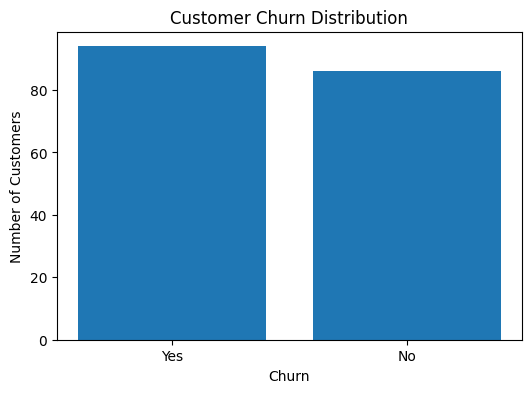

In [59]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## 15. Churn by Contract Type

Contract type may be associated with customer retention because customers with longer-term contracts may have different churn behavior compared with customers on monthly contracts.

The number and percentage of churned customers are compared across contract types to identify any observable relationship between contract duration and churn.

In [60]:
contract_churn = pd.crosstab(
    df["Contract_Type"],
    df["Churn"]
)

print("Churn counts by Contract Type:")
print(contract_churn)

print("\nChurn percentage within each Contract Type:")
print(
    pd.crosstab(
        df["Contract_Type"],
        df["Churn"],
        normalize="index"
    ).mul(100).round(2)
)

Churn counts by Contract Type:
Churn          No  Yes
Contract_Type         
1 Year         28   24
2 Year         19    5
Monthly        39   65

Churn percentage within each Contract Type:
Churn             No    Yes
Contract_Type              
1 Year         53.85  46.15
2 Year         79.17  20.83
Monthly        37.50  62.50


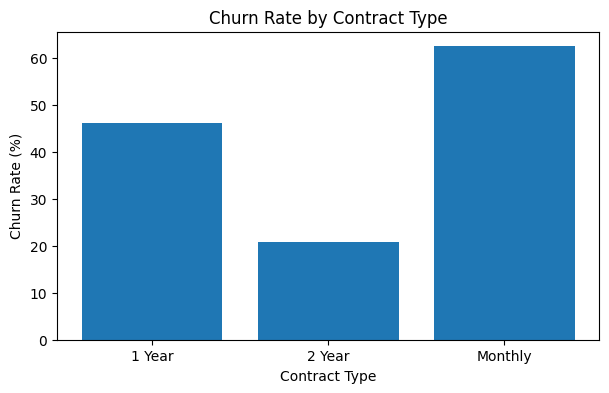

In [61]:
contract_churn_pct = (
    pd.crosstab(
        df["Contract_Type"],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100
)

plt.figure(figsize=(7, 4))
plt.bar(contract_churn_pct.index, contract_churn_pct.values)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

## 16. Churn by Satisfaction Score

Customer satisfaction may be associated with churn because customers with lower satisfaction scores may have different retention behavior than highly satisfied customers.

The churn rate is calculated for each satisfaction score to identify patterns between satisfaction and customer churn.

In [62]:
satisfaction_churn = (
    pd.crosstab(
        df["Satisfaction_Score"],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100
)

print("Churn rate by Satisfaction Score:")
print(satisfaction_churn.round(2))

Churn rate by Satisfaction Score:
Satisfaction_Score
1.0     68.42
2.0     45.45
3.0     69.23
4.0     55.56
5.0     66.67
6.0     51.85
7.0     43.75
8.0     50.00
9.0     43.48
10.0    29.41
Name: Yes, dtype: float64


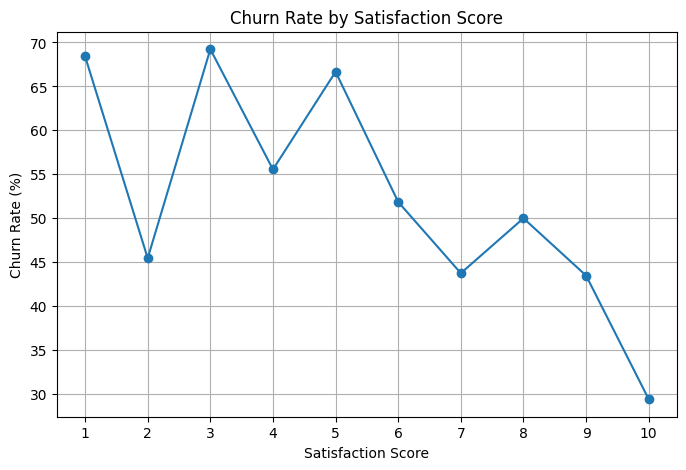

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(
    satisfaction_churn.index,
    satisfaction_churn.values,
    marker="o"
)

plt.title("Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate (%)")
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

## 17. Churn by Customer Tenure

Customer tenure represents how long a customer has been with the company.

To make the relationship easier to interpret, customers are grouped into tenure ranges. The churn rate is then calculated for each group.

This helps identify whether newer or longer-tenured customers show different churn behavior.

In [64]:
# Create tenure groups

df["Tenure_Group"] = pd.cut(
    df["Tenure_Months"],
    bins=[0, 12, 24, 48, float("inf")],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49+ Months"]
)

# Calculate churn rate for each tenure group
tenure_churn = (
    pd.crosstab(
        df["Tenure_Group"],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100
)

print("Churn rate by Tenure Group:")
print(tenure_churn.round(2))

Churn rate by Tenure Group:
Tenure_Group
0-12 Months     52.38
13-24 Months    36.36
25-48 Months    52.78
49+ Months      56.92
Name: Yes, dtype: float64


## 17.1 Churn Rate by Tenure Group

The churn rate across tenure groups is visualized to make differences in customer retention behavior easier to compare.

The visualization helps identify whether particular stages of the customer lifecycle are associated with higher observed churn.

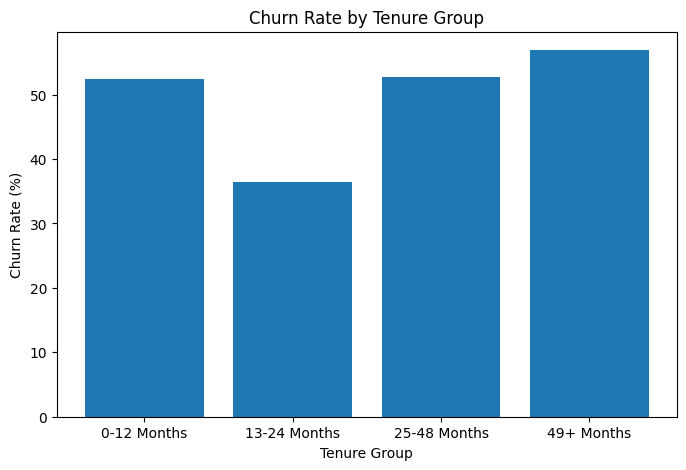

In [65]:
plt.figure(figsize=(8, 5))

plt.bar(
    tenure_churn.index.astype(str),
    tenure_churn.values
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.show()

## 18. Churn by Monthly Charges

Monthly charges represent the recurring amount paid by each customer.

To examine whether billing level is associated with churn, customers are divided into four groups based on the distribution of monthly charges. The churn rate is then calculated for each group.

Quartile-based groups are used so that customers are distributed approximately evenly across the charge ranges.

In [66]:
# Create monthly charge groups using quartiles

df["Monthly_Charge_Group"] = pd.qcut(
    df["Monthly_Charges"],
    q=4,
    labels=["Q1 - Lowest", "Q2", "Q3", "Q4 - Highest"]
)

# Calculate churn rate for each charge group
charge_churn = (
    pd.crosstab(
        df["Monthly_Charge_Group"],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100
)

print("Churn rate by Monthly Charge Group:")
print(charge_churn.round(2))

Churn rate by Monthly Charge Group:
Monthly_Charge_Group
Q1 - Lowest     51.11
Q2              53.06
Q3              46.34
Q4 - Highest    57.78
Name: Yes, dtype: float64


## 18.1 Churn Rate by Monthly Charge Group

The churn rate across monthly charge groups is visualized to compare customer churn at different billing levels.

The quartile groups allow customers with relatively lower and higher monthly charges to be compared without relying on arbitrary charge thresholds.

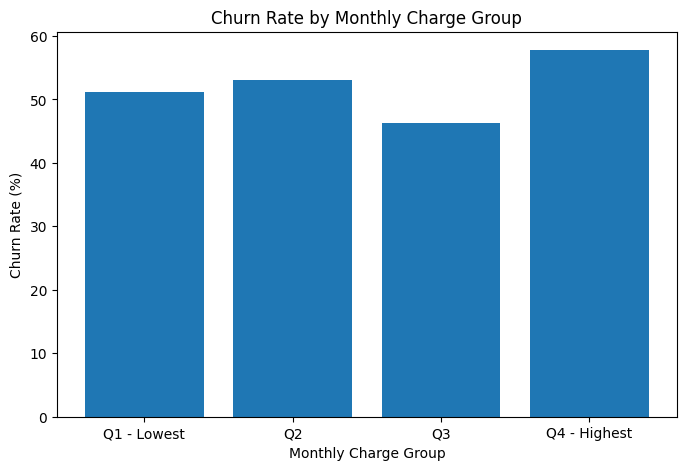

In [67]:
plt.figure(figsize=(8, 5))

plt.bar(
    charge_churn.index.astype(str),
    charge_churn.values
)

plt.title("Churn Rate by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")

plt.show()

## 19. Churn by Support Calls

The number of support calls made by a customer during the last three months may be associated with customer churn.

Customers are grouped according to their number of support calls, and the churn rate is calculated for each group.

This helps identify whether customers with higher support activity show different churn behavior.

In [68]:
# Create support call groups

df["Support_Call_Group"] = pd.cut(
    df["Support_Calls_Last_3M"],
    bins=[-1, 2, 5, float("inf")],
    labels=["0-2 Calls", "3-5 Calls", "6+ Calls"]
)

# Calculate churn rate
support_churn = (
    pd.crosstab(
        df["Support_Call_Group"],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100
)

print("Churn rate by Support Call Group:")
print(support_churn.round(2))

Churn rate by Support Call Group:
Support_Call_Group
0-2 Calls    52.31
3-5 Calls    48.51
6+ Calls     78.57
Name: Yes, dtype: float64


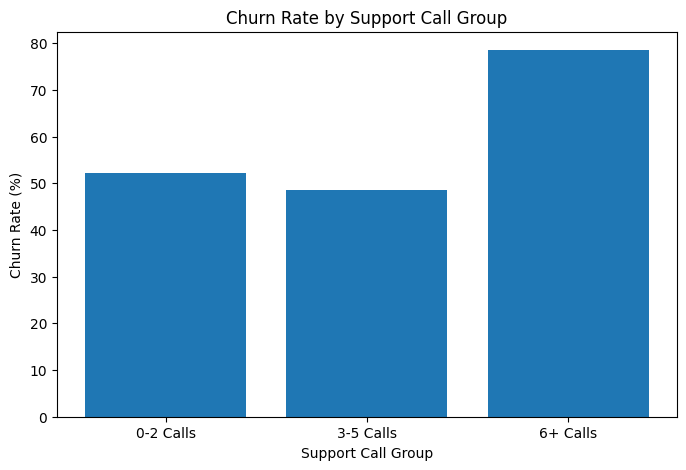

In [69]:
plt.figure(figsize=(8, 5))

plt.bar(
    support_churn.index.astype(str),
    support_churn.values
)

plt.title("Churn Rate by Support Call Group")
plt.xlabel("Support Call Group")
plt.ylabel("Churn Rate (%)")

plt.show()

## 20. Churn by Data Usage

Data usage represents the amount of data consumed by each customer.

To examine whether usage level is associated with churn, customers are divided into four groups based on their data usage distribution. The churn rate is then calculated for each group.

Quartile-based groups are used to create approximately equal-sized customer groups.

In [70]:
# Create data usage groups using quartiles

df["Data_Usage_Group"] = pd.qcut(
    df["Data_Usage_GB"],
    q=4,
    labels=["Q1 - Lowest", "Q2", "Q3", "Q4 - Highest"]
)

# Calculate churn rate for each usage group
usage_churn = (
    pd.crosstab(
        df["Data_Usage_Group"],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100
)

print("Churn rate by Data Usage Group:")
print(usage_churn.round(2))

Churn rate by Data Usage Group:
Data_Usage_Group
Q1 - Lowest     44.44
Q2              50.94
Q3              51.35
Q4 - Highest    62.22
Name: Yes, dtype: float64


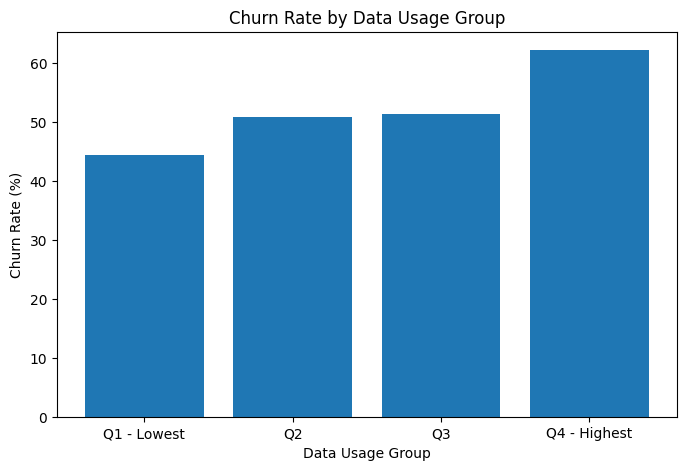

In [71]:
plt.figure(figsize=(8, 5))

plt.bar(
    usage_churn.index.astype(str),
    usage_churn.values
)

plt.title("Churn Rate by Data Usage Group")
plt.xlabel("Data Usage Group")
plt.ylabel("Churn Rate (%)")

plt.show()

## 21. EDA Summary

The exploratory analysis identified several observable patterns associated with customer churn:

1. **Contract Type:** Monthly-contract customers show a higher observed churn rate than customers on longer-term contracts.

2. **Satisfaction Score:** Higher satisfaction scores generally show lower observed churn rates, although the relationship is not perfectly consistent across all scores.

3. **Tenure:** Churn varies across tenure groups, with no simple linear relationship between tenure and churn.

4. **Monthly Charges:** Churn rates vary across monthly-charge groups, with the highest-charge group showing a relatively higher observed churn rate.

5. **Support Calls:** Customers with 6 or more support calls show substantially higher observed churn than customers with fewer support calls.

6. **Data Usage:** Customers in the highest data-usage group show a higher observed churn rate than customers in the lowest usage group.

These findings describe associations in the cleaned dataset and do not establish causal relationships. The identified variables will be considered as candidate predictors during the supervised machine learning stage.

In [72]:
eda_summary = pd.DataFrame({
    "Factor": [
        "Contract Type",
        "Satisfaction Score",
        "Tenure Group",
        "Monthly Charge Group",
        "Support Call Group",
        "Data Usage Group"
    ],
    "Observation": [
        "Monthly contracts show higher observed churn",
        "Higher satisfaction generally shows lower churn",
        "Churn varies across tenure groups",
        "Highest-charge group shows relatively higher churn",
        "6+ support calls show substantially higher churn",
        "Highest-usage group shows higher churn"
    ]
})

eda_summary

,Factor,Observation
0,Contract Type,Monthly contracts show higher observed churn
1,Satisfaction Score,Higher satisfaction generally shows lower churn
2,Tenure Group,Churn varies across tenure groups
3,Monthly Charge Group,Highest-charge group shows relatively higher c...
4,Support Call Group,6+ support calls show substantially higher churn
5,Data Usage Group,Highest-usage group shows higher churn


# 22. Feature and Target Definition

The target variable for the supervised learning problem is `Churn`, which indicates whether a customer churned (`Yes`) or did not churn (`No`).

`Customer_ID` is excluded because it is an identifier and does not represent a meaningful customer characteristic.

The grouping variables created during EDA (`Tenure_Group`, `Monthly_Charge_Group`, `Support_Call_Group`, and `Data_Usage_Group`) are also excluded from the initial model because they were created specifically for exploratory analysis.

The remaining demographic, usage, billing, service, and satisfaction variables are used as candidate predictors.

In [73]:
# Define target variable
y = df["Churn"]

# Define predictor columns
feature_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score",
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

X = df[feature_columns]

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.name)

print("\nFeature dataset shape:", X.shape)
print("Target shape:", y.shape)

Feature columns:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']

Target column:
Churn

Feature dataset shape: (180, 11)
Target shape: (180,)


# 23. Train-Test Split

The cleaned dataset is divided into training and testing sets before model development.

The training set will be used to train the machine learning models, while the testing set will be used later to evaluate how well the models perform on unseen customer data.

An 80/20 split is used. Stratification is applied using the target variable `Churn` so that both sets maintain a similar proportion of churned and non-churned customers.

A fixed random state is used to make the results reproducible.

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training feature shape: (144, 11)
Testing feature shape: (36, 11)

Training target distribution:
Churn
Yes    75
No     69
Name: count, dtype: int64

Testing target distribution:
Churn
Yes    19
No     17
Name: count, dtype: int64


# 24. Feature Preprocessing

The dataset contains both numerical and categorical predictor variables.

Numerical variables are standardized using `StandardScaler` so that variables with different scales do not disproportionately influence models such as Logistic Regression and KNN.

Categorical variables are converted into numerical form using One-Hot Encoding.

A `ColumnTransformer` is used to apply the appropriate preprocessing to each feature type. The preprocessing will be incorporated into the machine learning pipelines so that transformation parameters are learned only from the training data.

In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical features
numeric_features = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

# Categorical features
categorical_features = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numerical features:", numeric_features)
print("\nCategorical features:", categorical_features)
print("\nPreprocessing transformer created successfully.")

Numerical features: ['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']

Categorical features: ['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']

Preprocessing transformer created successfully.


# 25. Logistic Regression Model

Logistic Regression is used as the first baseline classification model because the target variable has two classes: `Yes` and `No`.

A pipeline is used to combine the preprocessing steps with the model. This ensures that the same transformations applied during training can also be applied consistently to the unseen test data.

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


# 26. Logistic Regression Predictions

The trained Logistic Regression model is used to predict the churn status of customers in the test set.

The test set represents unseen customer data and will be used to evaluate how well the model generalizes beyond the training data.

In [77]:
# Predict churn for the test set
y_pred_logistic = logistic_model.predict(X_test)

print("Predicted churn values:")
print(y_pred_logistic)

print("\nNumber of predictions:", len(y_pred_logistic))

Predicted churn values:
['No' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes'
 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'Yes'
 'No' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No' 'No' 'No']

Number of predictions: 36


# 27. Logistic Regression Evaluation

The Logistic Regression model is evaluated on the unseen test set using accuracy, precision, recall, and F1-score.

Since the business objective is to identify customers who may churn, the `Yes` class is treated as the positive class.

Recall is particularly important because it measures how many of the actual churned customers were correctly identified by the model.

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(
    y_test, y_pred_logistic, pos_label="Yes"
)
recall_logistic = recall_score(
    y_test, y_pred_logistic, pos_label="Yes"
)
f1_logistic = f1_score(
    y_test, y_pred_logistic, pos_label="Yes"
)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1-Score : {f1_logistic:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.6111
Precision: 0.6667
Recall   : 0.5263
F1-Score : 0.5882


# 28. Logistic Regression Confusion Matrix

A confusion matrix is used to examine the types of correct and incorrect predictions made by the Logistic Regression model.

This helps identify false negatives, where customers who actually churned were predicted as non-churners.

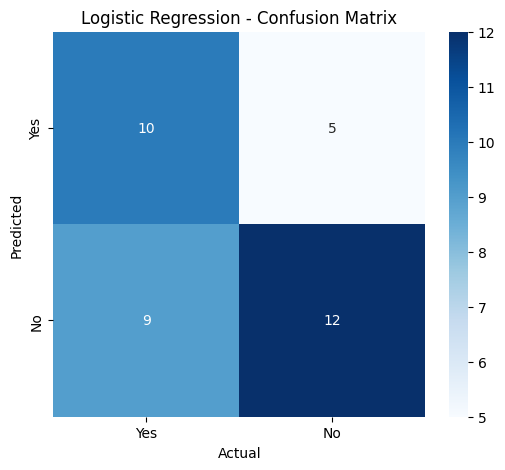

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=["Yes", "No"]
)

# Reverse axes so:
# Rows    = Predicted
# Columns = Actual
cm_logistic = cm_logistic.T

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Yes", "No"],
    yticklabels=["Yes", "No"]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# 29. K-Nearest Neighbors (KNN) Model

K-Nearest Neighbors (KNN) is used as the second classification model.

KNN predicts the class of a customer based on the classes of nearby observations in the feature space.

Because KNN is distance-based, numerical features are standardized during preprocessing.

In [81]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN pipeline
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]
)

# Train the model
knn_model.fit(X_train, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [82]:
# Predict churn for the test set
y_pred_knn = knn_model.predict(X_test)

print("KNN predicted churn values:")
print(y_pred_knn)

print("\nNumber of predictions:", len(y_pred_knn))

KNN predicted churn values:
['No' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'No'
 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'Yes'
 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes' 'No']

Number of predictions: 36


In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate KNN evaluation metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)

precision_knn = precision_score(
    y_test,
    y_pred_knn,
    pos_label="Yes"
)

recall_knn = recall_score(
    y_test,
    y_pred_knn,
    pos_label="Yes"
)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    pos_label="Yes"
)

print("KNN Performance")
print("----------------")
print(f"Accuracy : {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall   : {recall_knn:.4f}")
print(f"F1-Score : {f1_knn:.4f}")

KNN Performance
----------------
Accuracy : 0.4444
Precision: 0.4667
Recall   : 0.3684
F1-Score : 0.4118


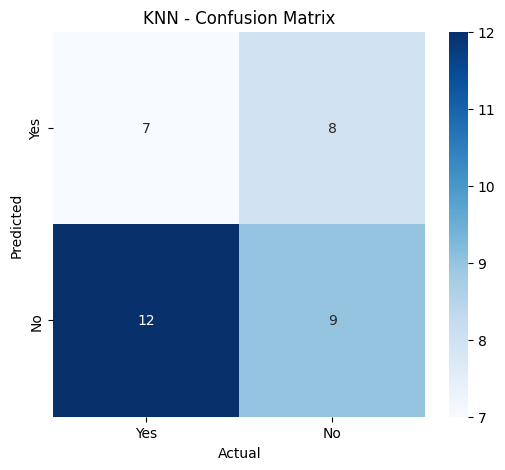

In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(
    y_test,
    y_pred_knn,
    labels=["Yes", "No"]
)

# Transpose so:
# Rows    = Predicted
# Columns = Actual
cm_knn = cm_knn.T

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Yes", "No"],
    yticklabels=["Yes", "No"]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("KNN - Confusion Matrix")
plt.show()

# 33. Decision Tree Model

A Decision Tree Classifier is used as the third supervised learning model.

The model creates decision rules based on customer characteristics to classify customers into churn and non-churn categories.

Decision Trees can capture non-linear relationships between predictor variables and the target.

In [85]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree pipeline
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [86]:
# Predict churn for the test set
y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree predicted churn values:")
print(y_pred_dt)

print("\nNumber of predictions:", len(y_pred_dt))

Decision Tree predicted churn values:
['No' 'No' 'Yes' 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes'
 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'Yes']

Number of predictions: 36


In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate Decision Tree evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    pos_label="Yes"
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    pos_label="Yes"
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    pos_label="Yes"
)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1-Score : {f1_dt:.4f}")

Decision Tree Performance
-------------------------
Accuracy : 0.5000
Precision: 0.5333
Recall   : 0.4211
F1-Score : 0.4706


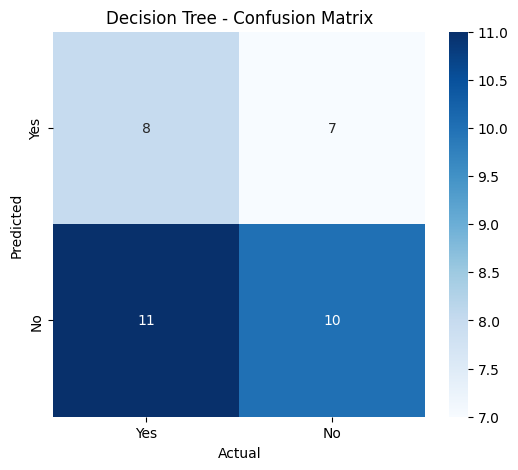

In [88]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt,
    labels=["Yes", "No"]
)

# Rows = Predicted
# Columns = Actual
cm_dt = cm_dt.T

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Yes", "No"],
    yticklabels=["Yes", "No"]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

# 36. Random Forest Model

Random Forest is used as the fourth classification model.

It combines multiple decision trees to produce a final prediction. Using multiple trees can provide a more robust model than relying on a single decision tree.

The model is trained using 100 trees with a fixed random state for reproducibility.

In [89]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [90]:
# Predict churn for the test set
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predicted churn values:")
print(y_pred_rf)

print("\nNumber of predictions:", len(y_pred_rf))

Random Forest predicted churn values:
['No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 'Yes'
 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'No' 'Yes'
 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'No']

Number of predictions: 36


In [91]:
# Calculate Random Forest evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    pos_label="Yes"
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    pos_label="Yes"
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    pos_label="Yes"
)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.5556
Precision: 0.6000
Recall   : 0.4737
F1-Score : 0.5294


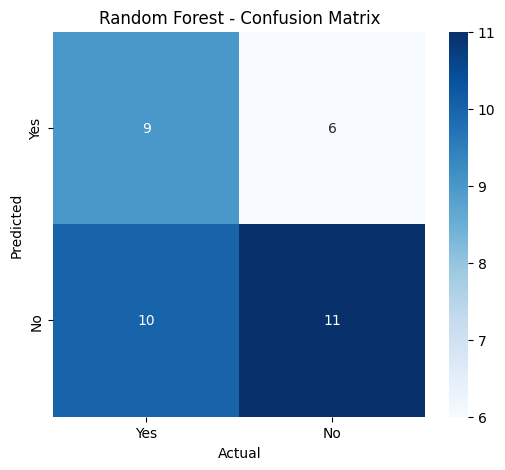

In [92]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["Yes", "No"]
)

# Rows = Predicted
# Columns = Actual
cm_rf = cm_rf.T

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Yes", "No"],
    yticklabels=["Yes", "No"]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest - Confusion Matrix")
plt.show()

# 39. Cross-Validation

Five-fold Stratified Cross-Validation is used to evaluate the stability of the classification models.

Stratification ensures that each fold maintains a similar proportion of churned and non-churned customers.

F1-score is used as the cross-validation metric because it balances precision and recall for the churn class.

Cross-validation provides a more reliable assessment of model performance than relying only on a single train-test split.

In [94]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score

# Create F1 scorer with "Yes" as the positive class
f1_scorer = make_scorer(
    f1_score,
    pos_label="Yes"
)

# Create 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation for each model
cv_logistic = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=f1_scorer
)

cv_knn = cross_val_score(
    knn_model,
    X_train,
    y_train,
    cv=cv,
    scoring=f1_scorer
)

cv_dt = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=cv,
    scoring=f1_scorer
)

cv_rf = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring=f1_scorer
)

print("5-Fold Cross-Validation F1-Scores")
print("----------------------------------")

print("Logistic Regression:", cv_logistic)
print("Mean:", round(cv_logistic.mean(), 4))

print("\nKNN:", cv_knn)
print("Mean:", round(cv_knn.mean(), 4))

print("\nDecision Tree:", cv_dt)
print("Mean:", round(cv_dt.mean(), 4))

print("\nRandom Forest:", cv_rf)
print("Mean:", round(cv_rf.mean(), 4))

5-Fold Cross-Validation F1-Scores
----------------------------------
Logistic Regression: [0.70967742 0.68965517 0.60606061 0.68571429 0.5625    ]
Mean: 0.6507

KNN: [0.62068966 0.4137931  0.66666667 0.77777778 0.53333333]
Mean: 0.6025

Decision Tree: [0.68571429 0.51612903 0.60606061 0.59259259 0.51851852]
Mean: 0.5838

Random Forest: [0.66666667 0.53333333 0.625      0.52941176 0.48275862]
Mean: 0.5674


# 40. Model Comparison

The models are compared using their performance on the held-out test set and their mean F1-score from 5-fold stratified cross-validation.

F1-score is emphasized because the objective is to identify customers who churn, while balancing precision and recall.

The cross-validation score also helps assess whether the observed test performance is stable across different training and validation subsets.

In [95]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Test Accuracy": [
        0.6111,
        0.4444,
        0.5000,
        0.5556
    ],
    "Test Precision": [
        0.6667,
        0.4667,
        0.5333,
        0.6000
    ],
    "Test Recall": [
        0.5263,
        0.3684,
        0.4211,
        0.4737
    ],
    "Test F1": [
        0.5882,
        0.4118,
        0.4706,
        0.5294
    ],
    "CV Mean F1": [
        cv_logistic.mean(),
        cv_knn.mean(),
        cv_dt.mean(),
        cv_rf.mean()
    ]
})

model_comparison

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,CV Mean F1
0,Logistic Regression,0.6111,0.6667,0.5263,0.5882,0.650721
1,KNN,0.4444,0.4667,0.3684,0.4118,0.602452
2,Decision Tree,0.5000,0.5333,0.4211,0.4706,0.583803
3,Random Forest,0.5556,0.6000,0.4737,0.5294,0.567434


# 41. Cross-Validation Stability Analysis

The test-set F1-score is compared with the mean cross-validation F1-score to assess the consistency of model performance.

A large difference between the two scores may indicate that performance varies depending on the data split, while a smaller difference suggests more consistent performance.

This comparison is used as supporting evidence when selecting the final model.

In [96]:
# Calculate the difference between CV F1 and test F1

model_comparison["CV-Test F1 Difference"] = (
    model_comparison["CV Mean F1"] - model_comparison["Test F1"]
)

model_comparison

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,CV Mean F1,CV-Test F1 Difference
0,Logistic Regression,0.6111,0.6667,0.5263,0.5882,0.650721,0.062521
1,KNN,0.4444,0.4667,0.3684,0.4118,0.602452,0.190652
2,Decision Tree,0.5000,0.5333,0.4211,0.4706,0.583803,0.113203
3,Random Forest,0.5556,0.6000,0.4737,0.5294,0.567434,0.038034


# 42. Logistic Regression Feature Importance

Logistic Regression provides coefficients that indicate how the model's predictors are associated with the predicted churn class.

Positive coefficients indicate a higher tendency toward the positive class (`Yes` = churn), while negative coefficients indicate a lower tendency toward churn.

The coefficients are interpreted as model associations and should not be treated as proof of causation.

In [97]:
# Get feature names after preprocessing
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logistic_model.named_steps["classifier"].coef_[0]

# Create feature importance table
logistic_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient for ranking
logistic_feature_importance["Absolute_Coefficient"] = (
    logistic_feature_importance["Coefficient"].abs()
)

# Sort by absolute coefficient
logistic_feature_importance = logistic_feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

logistic_feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
8,cat__Contract_Type_2 Year,-0.967122,0.967122
9,cat__Contract_Type_Monthly,0.871548,0.871548
6,num__Satisfaction_Score,-0.643202,0.643202
15,cat__Region_North,0.425386,0.425386
17,cat__Region_West,-0.354168,0.354168
4,num__Support_Calls_Last_3M,0.350241,0.350241
5,num__Data_Usage_GB,0.336832,0.336832
3,num__Monthly_Charges,0.304994,0.304994
18,cat__Plan_Type_Basic,0.244288,0.244288
10,cat__Payment_Method_Bank Transfer,0.232044,0.232044


# 43. Important Features from Logistic Regression

The Logistic Regression coefficients are summarized using simplified feature names for easier interpretation.

The magnitude of the coefficient indicates the strength of the model's association with the predicted churn class, while the sign indicates the direction of the association.

These results describe patterns identified by the model and do not establish causation.

In [98]:
# Create a cleaner version of the feature importance table
feature_summary = logistic_feature_importance.copy()

feature_summary["Feature"] = (
    feature_summary["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

feature_summary = feature_summary[
    ["Feature", "Coefficient", "Absolute_Coefficient"]
]

feature_summary.head(10)

,Feature,Coefficient,Absolute_Coefficient
8,Contract_Type_2 Year,-0.967122,0.967122
9,Contract_Type_Monthly,0.871548,0.871548
6,Satisfaction_Score,-0.643202,0.643202
15,Region_North,0.425386,0.425386
17,Region_West,-0.354168,0.354168
4,Support_Calls_Last_3M,0.350241,0.350241
5,Data_Usage_GB,0.336832,0.336832
3,Monthly_Charges,0.304994,0.304994
18,Plan_Type_Basic,0.244288,0.244288
10,Payment_Method_Bank Transfer,0.232044,0.232044


# 44. Final Model Selection

The four classification models were evaluated using test-set performance and 5-fold stratified cross-validation.

Logistic Regression achieved the highest mean cross-validation F1-score (0.6507) among the evaluated models. It also achieved a test F1-score of 0.5882, with 61.11% accuracy, 66.67% precision, and 52.63% recall.

The difference between its cross-validation F1-score and test F1-score was 0.0625, indicating a relatively small difference between the average cross-validation performance and the held-out test performance.

Based on these observed results, Logistic Regression is selected as the final model for this project.

This selection is based on the available dataset, the chosen evaluation metrics, and the observed validation results. Performance may vary on new customer data.

In [99]:
# Display the final model's performance

final_model_results = model_comparison[
    model_comparison["Model"] == "Logistic Regression"
]

final_model_results

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,CV Mean F1,CV-Test F1 Difference
0,Logistic Regression,0.6111,0.6667,0.5263,0.5882,0.650721,0.062521


In [100]:
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm_final = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=["Yes", "No"]
)

# Transpose so rows = Predicted and columns = Actual
cm_final = cm_final.T

print("Final Logistic Regression Confusion Matrix")
print("-------------------------------------------")
print(cm_final)

# Extract values
TP = cm_final[0, 0]
FP = cm_final[0, 1]
FN = cm_final[1, 0]
TN = cm_final[1, 1]

print("\nTrue Positives:", TP)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Negatives:", TN)

Final Logistic Regression Confusion Matrix
-------------------------------------------
[[10  5]
 [ 9 12]]

True Positives: 10
False Positives: 5
False Negatives: 9
True Negatives: 12


# 46. Final Logistic Regression Confusion Matrix

The confusion matrix shows how the final Logistic Regression model classified the 36 customers in the test set.

The rows represent the predicted class, while the columns represent the actual class.

The model correctly identified 10 customers who churned and 12 customers who did not churn. It incorrectly predicted 5 non-churned customers as churned and failed to identify 9 customers who actually churned.

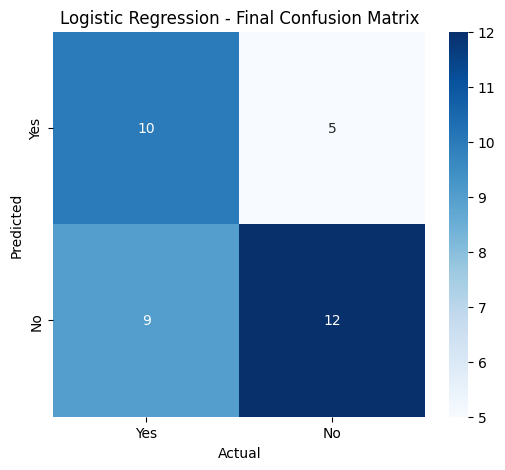

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Yes", "No"],
    yticklabels=["Yes", "No"]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Logistic Regression - Final Confusion Matrix")

plt.show()

# 47. Classification Threshold Analysis

Logistic Regression produces a probability of churn for each customer. By default, customers with a predicted churn probability of 0.50 or higher are classified as `Yes`.

Different thresholds can change the balance between recall and precision.

Since identifying customers who actually churn is important for the retention use case, several thresholds are examined to understand how recall and false negatives change.

The threshold analysis is exploratory and is performed on the held-out test set, so the results should not be treated as a new unbiased performance estimate.

In [102]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Get predicted probability of churn
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    
    y_pred_threshold = np.where(
        y_prob_logistic >= threshold,
        "Yes",
        "No"
    )
    
    precision = precision_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes",
        zero_division=0
    )
    
    recall = recall_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes",
        zero_division=0
    )
    
    f1 = f1_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes",
        zero_division=0
    )
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall,F1
0,0.3,0.538462,0.736842,0.622222
1,0.4,0.600000,0.631579,0.615385
2,0.5,0.666667,0.526316,0.588235
3,0.6,0.642857,0.473684,0.545455
4,0.7,0.555556,0.263158,0.357143


# 48. Threshold Analysis Findings

The default classification threshold of 0.50 produced a recall of 52.63% and an F1-score of 58.82%.

When the threshold was reduced to 0.30, recall increased to 73.68% and F1-score increased to 62.22%, while precision decreased to 53.85%.

This demonstrates the trade-off between identifying more potential churners and generating more false-positive alerts.

For a retention use case, a lower threshold may be considered when the business places greater importance on identifying potential churners. However, the appropriate threshold should be selected using validation data and business costs before deployment.

The threshold comparison here is exploratory because it was evaluated on the held-out test set.

In [103]:
best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.300000
Precision    0.538462
Recall       0.736842
F1           0.622222
Name: 0, dtype: float64

# 50. Key Business Insights

Based on the exploratory analysis and model results, the following observations were identified:

1. **Contract type is strongly associated with churn:** Monthly-contract customers had an observed churn rate of 62.50%, compared with 20.83% for 2-year contracts.

2. **Customer satisfaction is associated with churn:** Higher satisfaction scores generally showed lower observed churn. Customers with a satisfaction score of 10 had a churn rate of 29.41%, compared with 69.23% at a score of 3.

3. **Frequent support interactions are associated with higher churn:** Customers with 6 or more support calls in the last three months had an observed churn rate of 78.57%.

4. **Higher data usage was associated with higher churn:** The highest data-usage quartile had an observed churn rate of 62.22%, compared with 44.44% in the lowest quartile.

5. **The model can help identify potential churners:** Logistic Regression achieved a mean cross-validation F1-score of 65.07%. At the exploratory threshold of 0.30, recall increased to 73.68%, demonstrating that the model can identify more potential churners when the business prioritizes reducing missed churn cases.

```markdown
# 51. Business Recommendations

Based on the observed churn patterns and model results, the following actions can be considered:

1. **Focus retention efforts on monthly-contract customers:** Since monthly-contract customers showed a higher observed churn rate, the company can consider targeted retention offers, contract upgrade options, or incentives for longer-term plans.

2. **Proactively engage customers with frequent support interactions:** Customers with 6 or more support calls showed substantially higher observed churn. These customers can be prioritized for service-quality reviews and proactive follow-up.

3. **Monitor customers with lower satisfaction scores:** Lower satisfaction was generally associated with higher churn. Customer feedback, service recovery, and satisfaction-improvement initiatives can be used for customers showing signs of dissatisfaction.

4. **Use churn predictions to prioritize retention activities:** The Logistic Regression model can be used as a screening tool to identify customers with a higher predicted probability of churn. A lower classification threshold can be considered when the business wants to identify more potential churners, while recognizing that this may generate more false-positive alerts.

5. **Continuously evaluate the model with new customer data:** The current dataset is relatively small, so the model should be monitored and retrained as more customer data becomes available. Performance should also be validated on future unseen data before being used for automated decisions.
```


```markdown
# 52. Limitations

The following limitations should be considered when interpreting the results:

1. **Small dataset:** After removing exact duplicate records, the dataset contains 180 customer records. A larger dataset would provide more reliable estimates of model performance.

2. **Data quality issues:** The original dataset contained missing values, inconsistent categorical labels, placeholders, and unusual numerical values. These were investigated and cleaned, but some unusual observations were retained where they were not clearly invalid.

3. **Limited generalization:** The evaluation is based on one held-out test set and cross-validation on the training data. Performance on a different customer population may vary.

4. **Preprocessing limitation:** Missing values were imputed before the train-test split during the cleaning stage. For a fully leakage-free production workflow, imputation should be performed inside the preprocessing pipeline using statistics learned only from the training data.

5. **Threshold analysis limitation:** The classification threshold comparison was performed on the held-out test set for exploratory purposes. A final production threshold should be selected using validation data and business costs before deployment.

6. **Association does not imply causation:** The EDA findings show relationships between customer characteristics and observed churn, but they do not establish that these factors directly cause customers to churn.

7. **Further validation is required:** Before operational use, the model should be tested on a larger and more recent dataset and monitored over time.
```


```markdown id="42617"
# 53. Conclusion

This project developed a supervised machine learning approach to predict customer churn using demographic, billing, usage, service, contract, and satisfaction-related information.

The dataset was first investigated and cleaned by handling duplicate records, missing values, inconsistent categorical labels, placeholders, and invalid numerical values. Exploratory Data Analysis was then performed to identify customer characteristics associated with observed churn.

Four classification algorithms were evaluated:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest

Logistic Regression achieved a test accuracy of 61.11%, test F1-score of 58.82%, and mean 5-fold cross-validation F1-score of 65.07% on this dataset. Based on these observed results, Logistic Regression was selected as the final model.

The analysis also demonstrated the trade-off between precision and recall when changing the classification threshold. At the exploratory threshold of 0.30, recall increased to 73.68%, compared with 52.63% at the default threshold of 0.50.

The findings suggest that churn prediction can be used as a screening tool to help a retention team identify customers who may require proactive attention. However, the model should be further validated on larger and future customer datasets before being used in a production environment.

Overall, this project demonstrates the complete supervised learning workflow: data understanding, data cleaning, exploratory analysis, feature preparation, model training, evaluation, cross-validation, error analysis, threshold analysis, and business interpretation.
```


In [104]:
print("===== FINAL PROJECT CHECK =====")

print("\n1. Dataset")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\n2. Target Distribution")
print(df["Churn"].value_counts())

print("\n3. Model Comparison")
print(model_comparison)

print("\n4. Final Model")
print("Model: Logistic Regression")
print("Test Accuracy:", round(final_model_results["Test Accuracy"].iloc[0] * 100, 2), "%")
print("Test Precision:", round(final_model_results["Test Precision"].iloc[0] * 100, 2), "%")
print("Test Recall:", round(final_model_results["Test Recall"].iloc[0] * 100, 2), "%")
print("Test F1:", round(final_model_results["Test F1"].iloc[0] * 100, 2), "%")
print("CV Mean F1:", round(final_model_results["CV Mean F1"].iloc[0] * 100, 2), "%")

print("\n5. Threshold Analysis")
print(best_threshold_row)

print("\n===== CHECK COMPLETE =====")

===== FINAL PROJECT CHECK =====

1. Dataset
Rows: 180
Columns: 17
Missing values: 0
Duplicate rows: 0

2. Target Distribution
Churn
Yes    94
No     86
Name: count, dtype: int64

3. Model Comparison
                 Model  Test Accuracy  Test Precision  Test Recall  Test F1  \
0  Logistic Regression         0.6111          0.6667       0.5263   0.5882   
1                  KNN         0.4444          0.4667       0.3684   0.4118   
2        Decision Tree         0.5000          0.5333       0.4211   0.4706   
3        Random Forest         0.5556          0.6000       0.4737   0.5294   

   CV Mean F1  CV-Test F1 Difference  
0    0.650721               0.062521  
1    0.602452               0.190652  
2    0.583803               0.113203  
3    0.567434               0.038034  

4. Final Model
Model: Logistic Regression
Test Accuracy: 61.11 %
Test Precision: 66.67 %
Test Recall: 52.63 %
Test F1: 58.82 %
CV Mean F1: 65.07 %

5. Threshold Analysis
Threshold    0.300000
Precision    0.53

In [105]:
cleaned_columns = [
    "Customer_ID",
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score",
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type",
    "Churn"
]

cleaned_df = df[cleaned_columns].copy()

print("Cleaned dataset shape:", cleaned_df.shape)
print("\nColumns:")
print(cleaned_df.columns.tolist())
print("\nMissing values:", cleaned_df.isna().sum().sum())
print("Duplicate rows:", cleaned_df.duplicated().sum())

Cleaned dataset shape: (180, 13)

Columns:
['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']

Missing values: 0
Duplicate rows: 0


In [106]:
cleaned_df.to_csv(
    "cleaned_customer_churn.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
